# Deep SRQ PATH Restart Ablation (Serial + PATH Pool)

Compares PATH start strategies for DeepSRQ SRE solves using serial rollouts with a pooled PATH solver: pure starts plus random restarts, pure starts only, and random starts only.

In [ ]:
from pathlib import Path
import sys

ROOT = Path.cwd()
if ROOT.name == "bimatrix_game":
    BIMATRIX_DIR = ROOT
else:
    BIMATRIX_DIR = ROOT / "discrete_action_space" / "bimatrix_game"
DISCRETE_DIR = BIMATRIX_DIR.parent
for path in (BIMATRIX_DIR, DISCRETE_DIR):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

from experiment_harness import (
    BASE_SEED,
    DuelingDoubleDqnSreAgentConfig,
    run_deep_srq_ablation_variants,
    summarize_ablation_timing_rows,
)
from stats_utils import save_training_stats

In [ ]:
OUTPUT_ROOT = BIMATRIX_DIR / "ablation_runs" / "path_restarts"

SCENARIOS = ("scenario1", "scenario3")
N_EPISODES = 3000
ROBUST_EPSILON_START = 0.5
EPSILON_SCHEDULE = "linear"
USE_GPU = True
ABLATION_HYPERPARAMS = DuelingDoubleDqnSreAgentConfig(
    sre_solver_workers=8,
    epsilon_schedule=EPSILON_SCHEDULE,
    epsilon_robust_initial=ROBUST_EPSILON_START,
    sre_solver_name="path_c_pool",
)

RUN_VARIANTS = (
    {
        "label": "pure_plus_random20",
        "hyperparameter_overrides": {"sre_num_repeats": 20, "sre_include_pure_starts": True},
    },
    {
        "label": "pure_plus_random10",
        "hyperparameter_overrides": {"sre_num_repeats": 10, "sre_include_pure_starts": True},
    },
    {
        "label": "pure_only",
        "hyperparameter_overrides": {"sre_num_repeats": 0, "sre_include_pure_starts": True},
    },
    {
        "label": "random10_only",
        "hyperparameter_overrides": {"sre_num_repeats": 10, "sre_include_pure_starts": False},
    },
    {
        "label": "random5_only",
        "hyperparameter_overrides": {"sre_num_repeats": 5, "sre_include_pure_starts": False},
    },
)

In [ ]:
results = run_deep_srq_ablation_variants(
    variants=RUN_VARIANTS,
    scenarios=SCENARIOS,
    base_seed=BASE_SEED,
    output_root=OUTPUT_ROOT,
    use_gpu=USE_GPU,
    write_plots=False,
    n_episodes=N_EPISODES,
    hyperparameters=ABLATION_HYPERPARAMS,
)

save_training_stats(OUTPUT_ROOT / "path_restarts_manifest.txt", results)

Deep SRQ Scenario 1 | DeepSRQ vs DeepSRQ | eps0=0.5 | schedule=linear | solver=path_c_pool | seed=2025


scenario1:eps0.5_linear__pure_plus_random20:path_c_pool: 100%|██████████| 3000/3000 [29:55<00:00,  1.67it/s] 

Saved stats to /home/wowthecoder/SRE-DQN/discrete_action_space/bimatrix_game/ablation_runs/path_restarts/pure_plus_random20/scenario1/deepsrq_vs_deepsrq__eps0.5_linear__pure_plus_random20/training_stats.txt
Scenario 1 - DeepSRQ vs DeepSRQ - eps0.5_linear__pure_plus_random20
Wall clock: 1890.924s (31.52 min)
Episode time:   count=3000, mean=0.629519s (629519.20 us), min=0.000637s, max=4.270206s, std=0.398234s
SRE solve time: count=176510, mean=0.009721s (9721.19 us), min=0.002450s, max=0.104857s, std=0.008944s
Backend solve:  count=176510, mean=0.024392s (24392.16 us), min=0.013738s, max=0.137783s, std=0.008010s
  Agent 0 (DuelingDoubleDqnSreAgent)
    SRE solve:  count=176510, mean=0.009721s (9721.19 us), min=0.002450s, max=0.104857s, std=0.008944s
    Backend:    count=176510, mean=0.024392s (24392.16 us), min=0.013738s, max=0.137783s, std=0.008010s
    Update:     count=10732, mean=0.061520s (61519.59 us), min=0.029444s, max=1.245019s, std=0.018623s

Reward Summary
Scenario   | Pair 

Deep SRQ Scenario 1 | DeepSRQ vs DeepSRQ | eps0=0.5 | schedule=linear | solver=path_c_pool | seed=2026


scenario1:eps0.5_linear__pure_plus_random10:path_c_pool: 100%|██████████| 3000/3000 [21:11<00:00,  2.36it/s]

...

Saved stats to /home/wowthecoder/SRE-DQN/discrete_action_space/bimatrix_game/ablation_runs/path_restarts/random10_only/scenario3/deepsrq_vs_deepsrq__eps0.5_linear__random10_only/training_stats.txt
Scenario 3 - DeepSRQ vs DeepSRQ - eps0.5_linear__random10_only
Wall clock: 993.276s (16.55 min)
Episode time:   count=3000, mean=0.330293s (330292.90 us), min=0.001508s, max=2.259866s, std=0.184048s
SRE solve time: count=279521, mean=0.002738s (2737.84 us), min=0.000871s, max=0.041373s, std=0.002785s
Backend solve:  count=279521, mean=0.007689s (7689.09 us), min=0.004240s, max=0.048145s, std=0.001589s
  Agent 0 (DuelingDoubleDqnSreAgent)
    SRE solve:  count=279521, mean=0.002738s (2737.84 us), min=0.000871s, max=0.041373s, std=0.002785s
    Backend:    count=279521, mean=0.007689s (7689.09 us), min=0.004240s, max=0.048145s, std=0.001589s
    Update:     count=15488, mean=0.025616s (25616.44 us), min=0.016904s, max=0.091099s, std=0.003554s

Reward Summary
Scenario   | Pair               | Ag

Deep SRQ Scenario 3 | DeepSRQ vs DeepSRQ | eps0=0.5 | schedule=linear | solver=path_c_pool | seed=3029


scenario3:eps0.5_linear__random5_only:path_c_pool: 100%|██████████| 3000/3000 [10:54<00:00,  4.58it/s]

Saved stats to /home/wowthecoder/SRE-DQN/discrete_action_space/bimatrix_game/ablation_runs/path_restarts/random5_only/scenario3/deepsrq_vs_deepsrq__eps0.5_linear__random5_only/training_stats.txt
Scenario 3 - DeepSRQ vs DeepSRQ - eps0.5_linear__random5_only
Wall clock: 687.160s (11.45 min)
Episode time:   count=3000, mean=0.228302s (228301.59 us), min=0.000458s, max=1.148133s, std=0.122691s
SRE solve time: count=283305, mean=0.001663s (1662.56 us), min=0.000513s, max=0.043352s, std=0.001696s
Backend solve:  count=283305, mean=0.004405s (4404.99 us), min=0.002446s, max=0.042644s, std=0.000959s
  Agent 0 (DuelingDoubleDqnSreAgent)
    SRE solve:  count=283305, mean=0.001663s (1662.56 us), min=0.000513s, max=0.043352s, std=0.001696s
    Backend:    count=283305, mean=0.004405s (4404.99 us), min=0.002446s, max=0.042644s, std=0.000959s
    Update:     count=15697, mean=0.018234s (18233.52 us), min=0.012401s, max=0.058314s, std=0.002494s

Reward Summary
Scenario   | Pair               | Agent

PosixPath('/home/wowthecoder/SRE-DQN/discrete_action_space/bimatrix_game/ablation_runs/path_restarts/path_restarts_manifest.txt')

In [4]:
for row in summarize_ablation_timing_rows(results):
    print(row)

{'scenario': 'scenario1', 'variant': 'pure_plus_random20', 'mode': 'serial', 'wall_seconds': 1890.9239869609996, 'env_steps': 43927, 'steps_per_second': 23.23044199708806, 'sre_count': 176510, 'mean_sre_ms': 9.721190418282454, 'backend_count': 176510, 'mean_backend_ms': 24.392156176602562, 'agent1_mean_last': 76.897, 'agent2_mean_last': 78.991}
{'scenario': 'scenario1', 'variant': 'pure_plus_random10', 'mode': 'serial', 'wall_seconds': 1339.4338281909995, 'env_steps': 42568, 'steps_per_second': 31.78059199646399, 'sre_count': 171804, 'mean_sre_ms': 6.808597856685554, 'backend_count': 171804, 'mean_backend_ms': 17.337130755138745, 'agent1_mean_last': 78.569, 'agent2_mean_last': 80.016}
{'scenario': 'scenario1', 'variant': 'pure_only', 'mode': 'serial', 'wall_seconds': 1003.026585183, 'env_steps': 46784, 'steps_per_second': 46.64283149729712, 'sre_count': 188298, 'mean_sre_ms': 4.353472750326827, 'backend_count': 188298, 'mean_backend_ms': 10.059280918087458, 'agent1_mean_last': 81.243, 

In [5]:
def _fmt(value, kind):
    if value is None:
        return "-"
    if kind == "int":
        return f"{int(value):,}"
    if kind == "float1":
        return f"{float(value):,.1f}"
    if kind == "float2":
        return f"{float(value):,.2f}"
    return str(value)


def print_pretty_table(rows, columns):
    rendered = []
    headers = [title for _, title, _ in columns]
    for row in rows:
        rendered.append([_fmt(row.get(key), kind) for key, _, kind in columns])
    widths = [len(header) for header in headers]
    for row in rendered:
        widths = [max(width, len(value)) for width, value in zip(widths, row)]
    header_line = " | ".join(header.ljust(width) for header, width in zip(headers, widths))
    separator = "-+-".join("-" * width for width in widths)
    print(header_line)
    print(separator)
    for row in rendered:
        print(" | ".join(value.ljust(width) for value, width in zip(row, widths)))


CASE_LABELS = {
    "pure_plus_random20": "Pure + 20 random",
    "pure_plus_random10": "Pure + 10 random",
    "pure_only": "Pure only",
    "random10_only": "10 random only",
    "random5_only": "5 random only",
}


summary_rows = []
for row in summarize_ablation_timing_rows(results):
    stats = results[row["scenario"]][row["variant"]]
    summary_rows.append({
        **row,
        "case": CASE_LABELS.get(row["variant"], row["variant"]),
        "epsilon": stats["epsilon_robust_initial"],
        "schedule": stats["epsilon_schedule"],
        "repeats": stats["hyperparameters"].get("sre_num_repeats"),
        "pure_starts": stats["hyperparameters"].get("sre_include_pure_starts"),
    })

summary_rows.sort(key=lambda row: (row["scenario"], row["repeats"], row["case"]))

print_pretty_table(
    summary_rows,
    columns=(
        ("scenario", "Scenario", "str"),
        ("epsilon", "Eps0", "float2"),
        ("schedule", "Schedule", "str"),
        ("case", "Case", "str"),
        ("pure_starts", "Pure", "str"),
        ("repeats", "Repeats", "int"),
        ("env_steps", "Env Steps", "int"),
        ("wall_seconds", "Wall s", "float1"),
        ("steps_per_second", "Steps/s", "float2"),
        ("mean_sre_ms", "SRE ms", "float2"),
        ("mean_backend_ms", "Backend ms", "float2"),
        ("agent1_mean_last", "A1 Last", "float2"),
        ("agent2_mean_last", "A2 Last", "float2"),
    ),
)


Scenario  | Eps0 | Schedule | Case             | Pure  | Repeats | Env Steps | Wall s  | Steps/s | SRE ms | Backend ms | A1 Last | A2 Last
----------+------+----------+------------------+-------+---------+-----------+---------+---------+--------+------------+---------+--------
scenario1 | 0.50 | linear   | Pure only        | True  | 0       | 46,784    | 1,003.0 | 46.64   | 4.35   | 10.06      | 81.24   | 85.56  
scenario1 | 0.50 | linear   | 5 random only    | False | 5       | 44,600    | 487.7   | 91.46   | 1.83   | 4.32       | 76.64   | 78.88  
scenario1 | 0.50 | linear   | 10 random only   | False | 10      | 44,389    | 754.8   | 58.81   | 3.23   | 8.17       | 78.42   | 79.84  
scenario1 | 0.50 | linear   | Pure + 10 random | True  | 10      | 42,568    | 1,339.4 | 31.78   | 6.81   | 17.34      | 78.57   | 80.02  
scenario1 | 0.50 | linear   | Pure + 20 random | True  | 20      | 43,927    | 1,890.9 | 23.23   | 9.72   | 24.39      | 76.90   | 78.99  
scenario3 | 0.50 | linear  

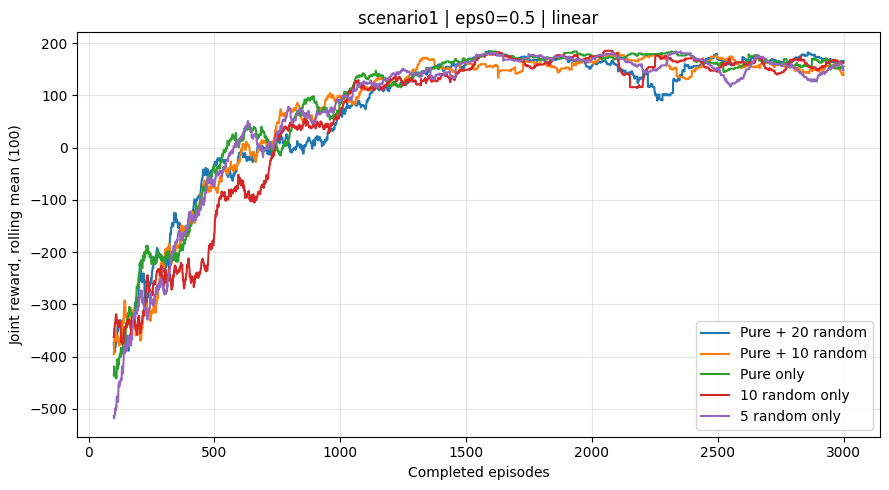

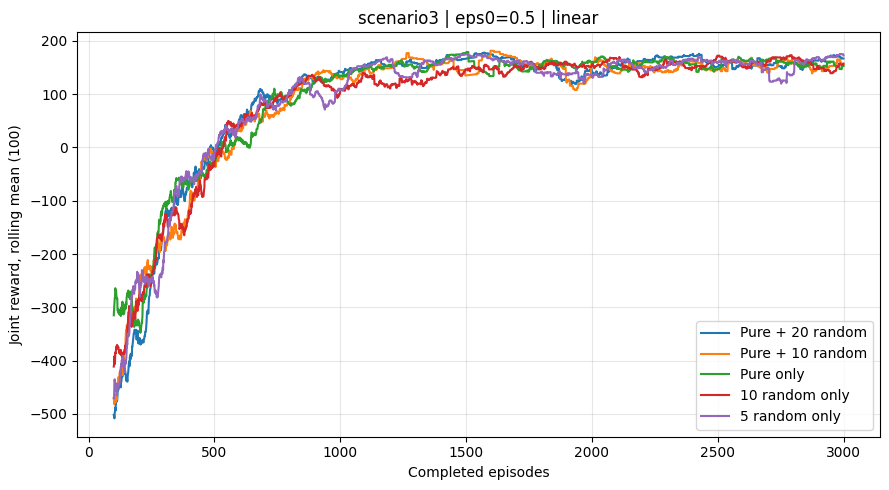

In [6]:
import matplotlib.pyplot as plt
import numpy as np


def rolling_mean(values, window=100):
    values = np.asarray(values, dtype=float)
    if values.size == 0:
        return values
    window = max(1, min(int(window), values.size))
    kernel = np.ones(window, dtype=float) / window
    return np.convolve(values, kernel, mode="valid")


ROLLING_WINDOW = 100

for scenario_key in SCENARIOS:
    fig, ax = plt.subplots(figsize=(9, 5))
    for variant in RUN_VARIANTS:
        stats = results[scenario_key][variant["label"]]
        rewards = stats["rewards"]
        min_len = min(len(rewards[0]), len(rewards[1]))
        if min_len == 0:
            continue
        joint_reward = np.asarray(rewards[0][:min_len], dtype=float) + np.asarray(rewards[1][:min_len], dtype=float)
        smoothed = rolling_mean(joint_reward, window=ROLLING_WINDOW)
        x = np.arange(smoothed.size) + min(ROLLING_WINDOW, joint_reward.size)
        ax.plot(x, smoothed, label=CASE_LABELS.get(variant["label"], variant["label"]))
    ax.set_title(f"{scenario_key} | eps0={ROBUST_EPSILON_START:g} | {EPSILON_SCHEDULE}")
    ax.set_xlabel("Completed episodes")
    ax.set_ylabel(f"Joint reward, rolling mean ({ROLLING_WINDOW})")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best")
    fig.tight_layout()
    plt.savefig(OUTPUT_ROOT / f"reward_curves_{scenario_key}.png")
    plt.show()
